# Spectral Graph Theory applied to spatialized single cell transcriptomics

#  intro

##  AnnData from MERFISH mouse cortex CSV 


In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
import matplotlib.pyplot as plt

CSV_PATH = "/home/asalmona/Documents/Ricci/data/MERFISH_LUNA_small_cortex/MERFISH_mouse_cortex_test.csv"
CELL_SECTION = "mouse2_slice219"
sample_id = "mouse2_sample5"
N_GENE_COLS = 254


## after import

In [2]:
# Load CSV (first column is an index)
df = pd.read_csv(CSV_PATH, index_col=0)
print(df.shape)
print("First columns:", list(df.columns[:5]))
print("Last columns:", list(df.columns[-10:]))

# Filter one slice
df = df[df["cell_section"] == CELL_SECTION].copy()
print("After filtering:", df.shape)

# Transcriptome matrix = first N_GENE_COLS columns
gene_cols = list(df.columns[:N_GENE_COLS])

# Build X / var
X = csr_matrix(df[gene_cols].to_numpy(dtype=np.float32))
var = pd.DataFrame(index=gene_cols)

# Build obs with metadata + cell types
obs_cols = [
    "cell_name",
    "coord_X",
    "coord_Y",
    "class",
    "cell_class",
    "mouse",
    "sample_id",
    "cell_section",
]
obs = df[obs_cols].copy()

# Make sure types are categorical for plotting
for c in ["class", "cell_class", "mouse", "sample_id", "cell_section"]:
    obs[c] = pd.Categorical(obs[c])

# Use cell_name as obs_names if unique; otherwise keep the CSV index
if obs["cell_name"].is_unique:
    obs.index = obs["cell_name"].astype(str)

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.obsm["spatial"] = obs[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32)

adata

(118036, 262)
First columns: ['1700022I11Rik', '1810046K07Rik', '5031425F14Rik', '5730522E02Rik', 'Acta2']
Last columns: ['Penk', 'Gad1', 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section']
After filtering: (3560, 262)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'

In [3]:
# Quick sanity checks
print(adata)
print("X shape:", adata.X.shape)
print("# genes kept:", adata.n_vars)
print("cell_section counts:\n", adata.obs["cell_section"].value_counts())

# Example: plot cell types in space (optional)
# import scanpy as sc
# sc.pl.spatial(adata, color="cell_class", spot_size=10, frameon=False)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'
X shape: (3560, 254)
# genes kept: 254
cell_section counts:
 cell_section
mouse2_slice219    3560
Name: count, dtype: int64


## plots

/tmp/ipykernel_152397/2702015068.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="Acta2", spot_size=20, frameon=False, cmap="Reds")


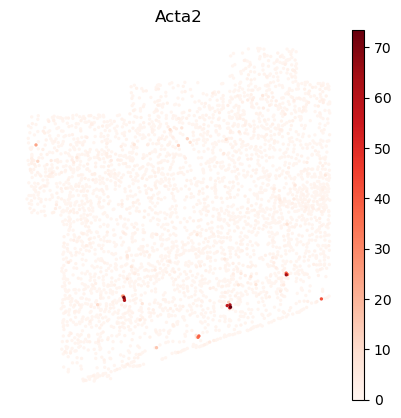

In [4]:
sc.pl.spatial(adata, color="Acta2", spot_size=20, frameon=False, cmap="Reds")

In [5]:
from spatial_correlation import spatial_gene_distance_grid

gene_names = adata.var_names.tolist()

top_genes_dict = {'000': 0}
minmax_gene, minmax_gene_var = '000', 0

for gene in gene_names:
    dist = spatial_gene_distance_grid(adata, gene, 1000)
    var = dist.variance
    if len(top_genes_dict) < 12:
        top_genes_dict[gene] = var
        if var < minmax_gene_var:
            minmax_gene, minmax_gene_var = gene, var
    else:
        if var > minmax_gene_var:
            top_genes_dict.pop(minmax_gene)
            top_genes_dict[gene] = var
            # gets the new minmax gene from the top 10
            minmax_gene = min(top_genes_dict, key=top_genes_dict.get)
            minmax_gene_var = top_genes_dict[minmax_gene]

top_genes = list(top_genes_dict.keys())

In [6]:
print(top_genes)

['Adamts4', 'Cux2', 'Igfbp5', 'Ptprt', 'Sema5a', 'Slc30a3', 'Sox10', 'Spon1', 'Sulf2', 'Syt6', 'Unc5b', 'Unc5d']


Adamts4 with variance 14.238651718252187
Cux2 with variance 12.55747175081459
Igfbp5 with variance 37.48993646268487
Ptprt with variance 18.040254286964064
Sema5a with variance 8.945350853475418
Slc30a3 with variance 20.90795230865518
Sox10 with variance 18.84262258284331
Spon1 with variance 13.88338389930907
Sulf2 with variance 36.54328484807353
Syt6 with variance 10.71748598582443
Unc5b with variance 11.05593483847715
Unc5d with variance 1.599944945129264


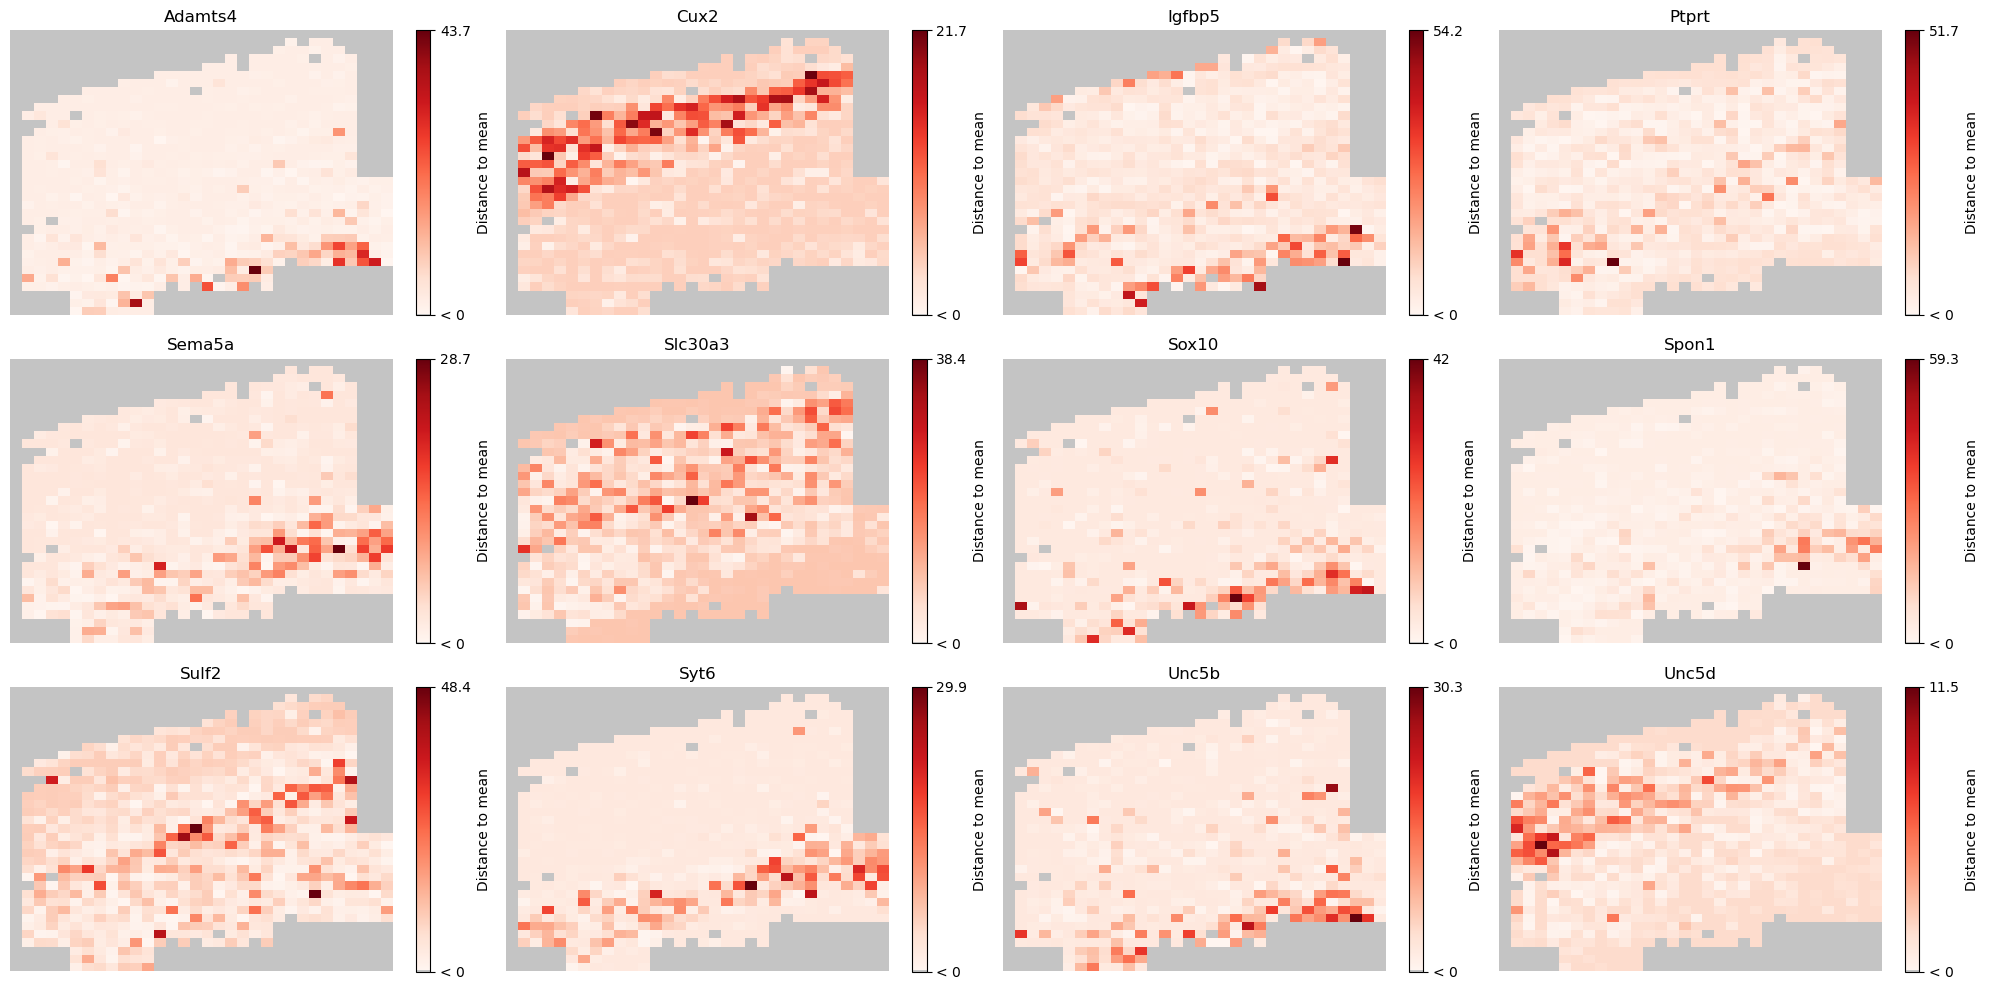

In [7]:
list_of_grids = []
for gene in top_genes:
    dist = spatial_gene_distance_grid(adata, gene, 60)
    list_of_grids.append(dist)

# Plot all grids in a single figure
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, dist in enumerate(list_of_grids):

    dist.plot_distance(ax=axes[i], cmap="Reds")
    axes[i].set_title(f"{top_genes[i]}")
    axes[i].axis('off')
    print(f"{top_genes[i]} with variance {dist.variance}")

plt.tight_layout()
plt.show()

In [8]:
low_genes_dict = {'ttt': 10000}
maxmin_gene, maxmin_gene_var = 'ttt', 10000

for gene in gene_names:
    dist = spatial_gene_distance_grid(adata, gene, 1000)
    var = dist.variance
    if len(low_genes_dict) < 12:
        low_genes_dict[gene] = var
        if var > maxmin_gene_var:
            maxmin_gene, maxmin_gene_var = gene, var
    else:
        if var < maxmin_gene_var:
            low_genes_dict.pop(maxmin_gene)
            low_genes_dict[gene] = var
            # gets the new minmax gene from the top 10
            maxmin_gene = max(low_genes_dict, key=low_genes_dict.get)
            maxmin_gene_var = low_genes_dict[maxmin_gene]

top_genes = list(top_genes_dict.keys())

1700022I11Rik with variance 0.0050413959313782
5031425F14Rik with variance 0.005083508215652942
5730522E02Rik with variance 0.0062137412833063906
Ccdc162 with variance 0.0063799564942685644
Clrn1 with variance 0.00463866573342273
Dmkn with variance 0.014508428158479194
Fndc7 with variance 0.004335228606827443
Ltf with variance 0.005893453842808462
Mrgprx2 with variance 0.002503679167866758
Muc20 with variance 0.010886293817846246
Olah with variance 0.01723741148267296
Prok2 with variance 0.0030813680031054184


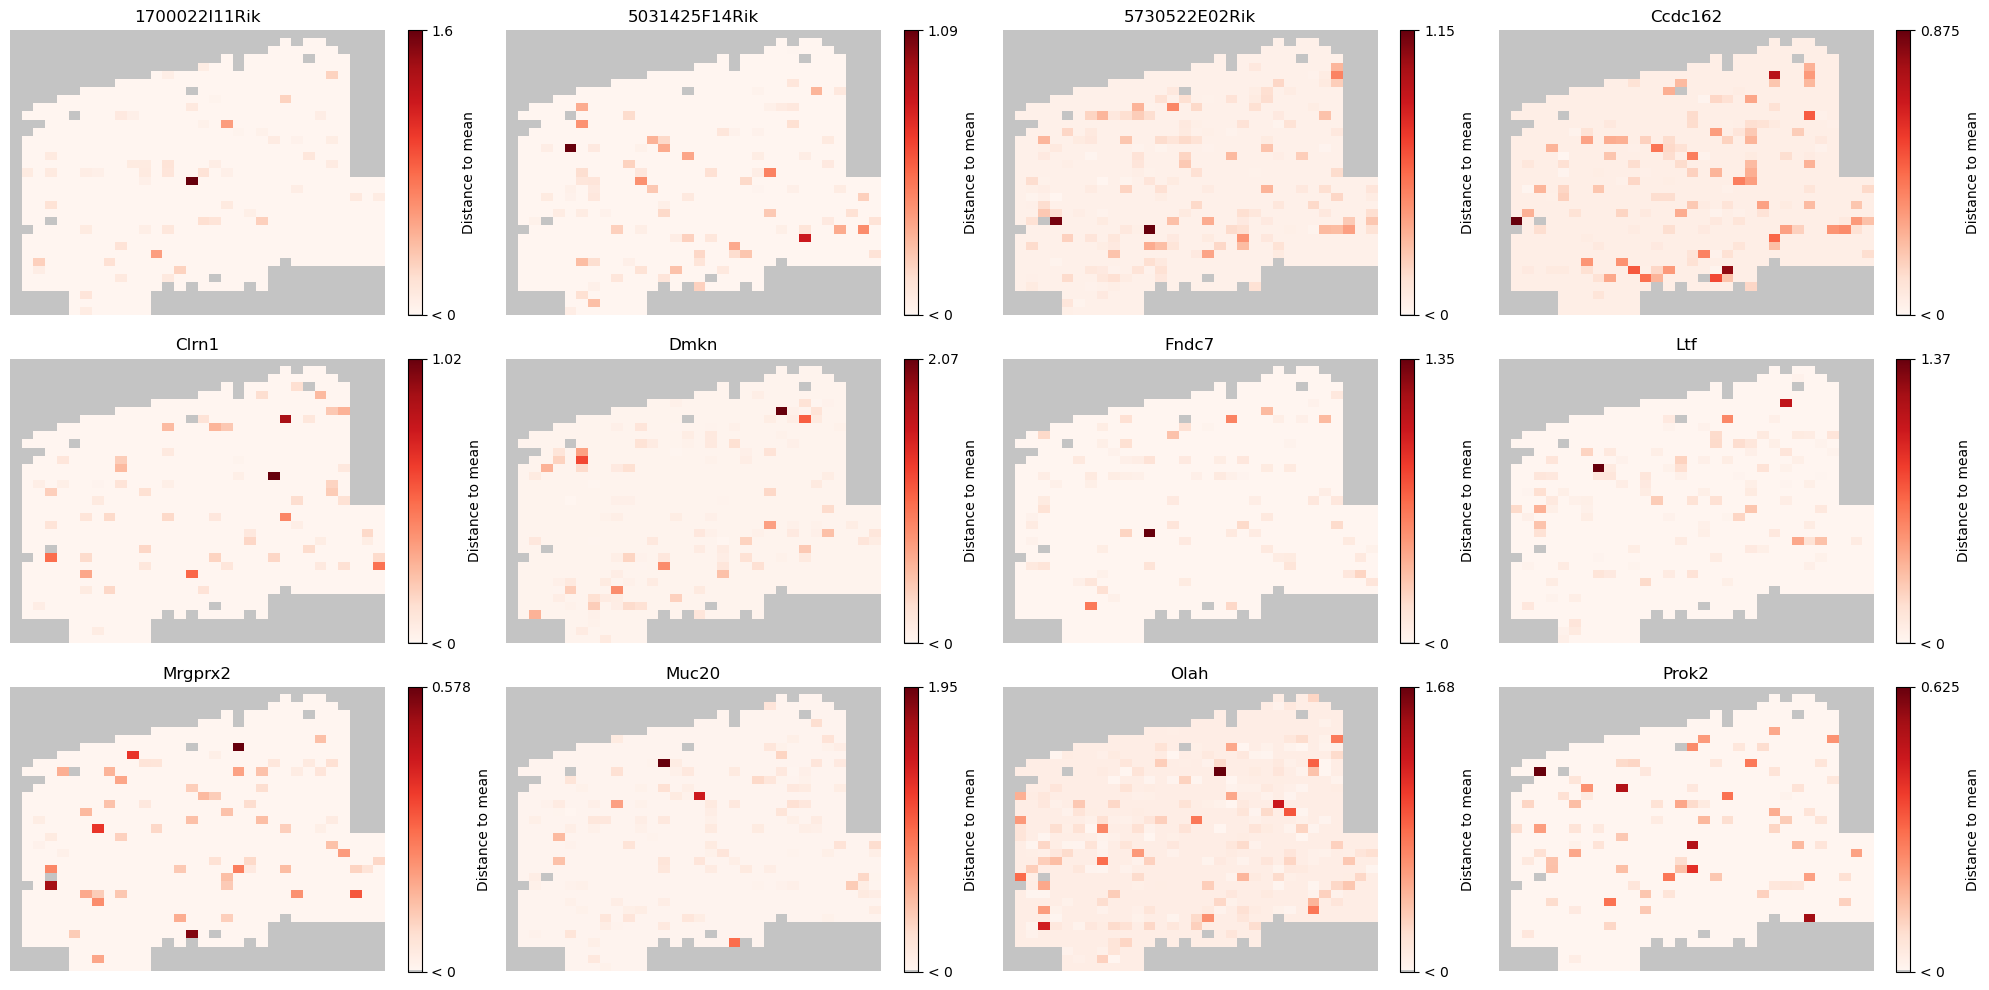

In [9]:
low_genes = list(low_genes_dict.keys())

list_of_grids = []
for gene in low_genes:
    dist = spatial_gene_distance_grid(adata, gene, 60)
    list_of_grids.append(dist)

# Plot all grids in a single figure
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, dist in enumerate(list_of_grids):

    dist.plot_distance(ax=axes[i], cmap="Reds")
    axes[i].set_title(f"{low_genes[i]}")
    axes[i].axis('off')
    print(f"{low_genes[i]} with variance {dist.variance}")

plt.tight_layout()
plt.show()

## comparing test and ground truth samples

here we will take a sample with prediction and ground truth and try to measure the correctness of the preidction with different metrics

In [2]:
pred = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_pred.csv'
ground_truth = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_true.csv'

# load the samples
whole_pred_sample = pd.read_csv(pred)
whole_ground_truth_sample = pd.read_csv(ground_truth)

# get only the VLMC cells
pred_sample = whole_pred_sample[whole_pred_sample['cell_class'] == 'VLMC']
ground_truth_sample = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'VLMC']


In [8]:
# plot points of a particular cell type in space using matplotlib

def plot_cell_type(df, cell_type_value, cell_type_col="cell_class", x_col="coord_X", y_col="coord_Y"):
    subset = df[df[cell_type_col] == cell_type_value]
    plt.figure(figsize=(6, 6))
    plt.scatter(subset[x_col], subset[y_col], s=30, alpha=0.7)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{cell_type_value} cells in spatial coordinates')
    plt.axis('equal')
    plt.show()

# Example usage:
# plot_cell_type(pred_sample, 'Astrocyte')

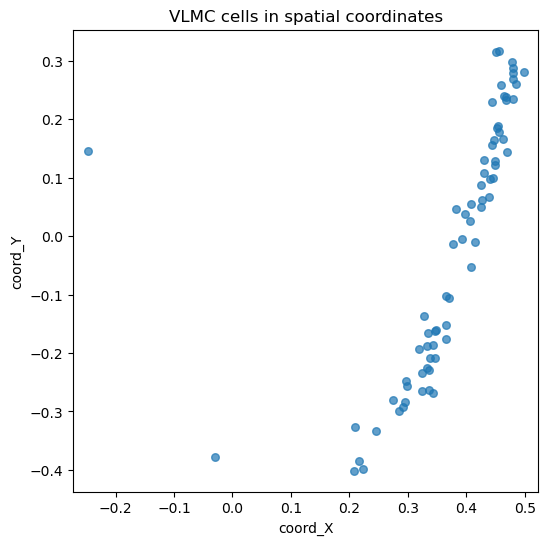

In [9]:
plot_cell_type(pred_sample, 'VLMC')

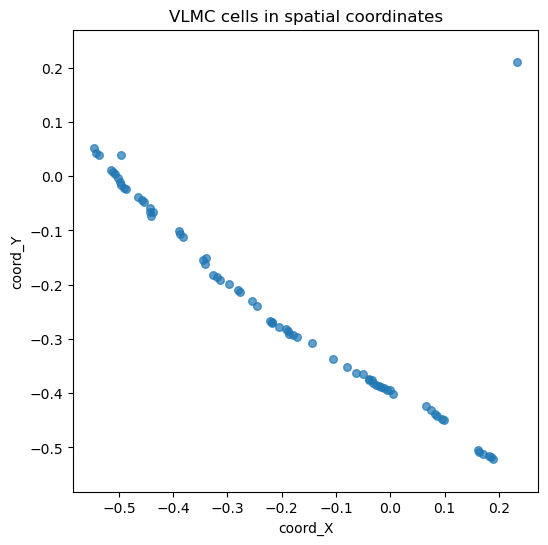

In [10]:
plot_cell_type(ground_truth_sample, 'VLMC')

In [11]:
from spectral_graph import align_prediction_rigid_to_ground_truth_by_id

# Align predicted coordinates to ground truth by cell ID
aligned_pred_sample = align_prediction_rigid_to_ground_truth_by_id(
    ground_truth_sample,
    pred_sample,
    cell_class_value='VLMC',
    id_col=0,
    coord_cols=('coord_X', 'coord_Y'),
    cell_class_col='cell_class',
    allow_reflection=False,
)


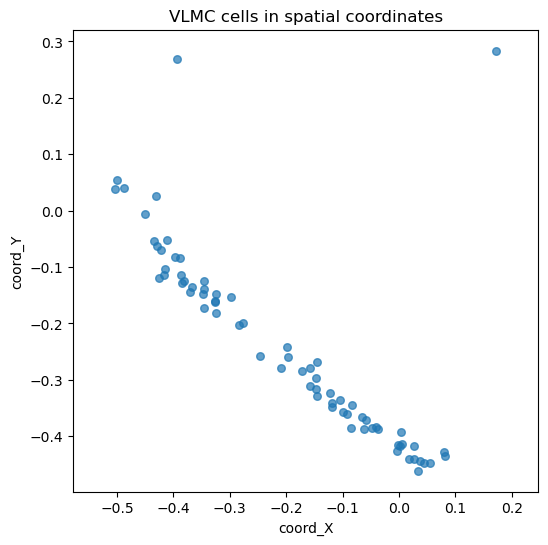

In [12]:
plot_cell_type(aligned_pred_sample, 'VLMC')

# Von Neumann Entropy

## defining and introducing concepts

In [13]:
from spectral_graph import spectral_laplacian_spectrum_by_cell_class

# Compute spectral Laplacian spectrum for VLMC cells
spectral_result = spectral_laplacian_spectrum_by_cell_class(
    aligned_pred_sample,
    cell_class_value='VLMC',
    mode='radius',
    k=None,
    radius=0.025,
    weight='distance',
    sigma=None,
    laplacian='normalized',
    n_eigs=10,
    drop_self_loops=True,
    random_state=0,
)


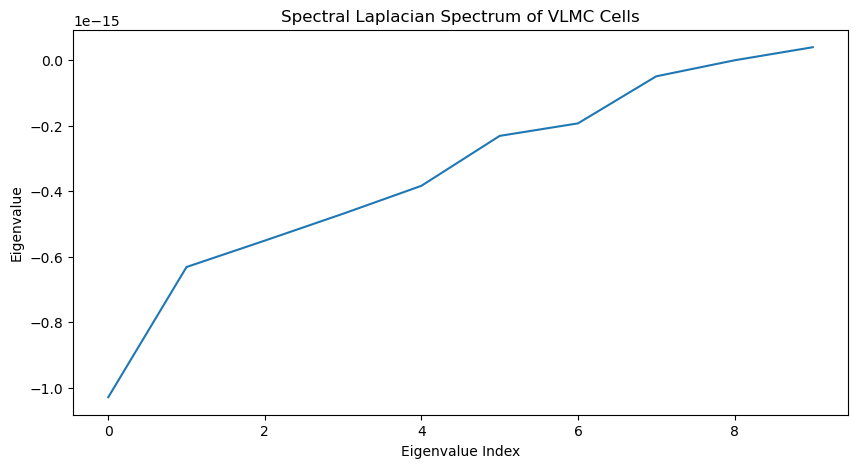

In [14]:
# Plot the spectrum
plt.figure(figsize=(10, 5))
plt.plot(spectral_result.eigenvalues)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Spectral Laplacian Spectrum of VLMC Cells')
plt.show()

[-8.65208845e-16 -7.95683492e-16 -7.15065639e-16 -5.13000461e-16
 -3.45416259e-16 -2.31653877e-16 -2.24014207e-16 -1.99258179e-17
  1.94458745e-17  8.41366667e-17]


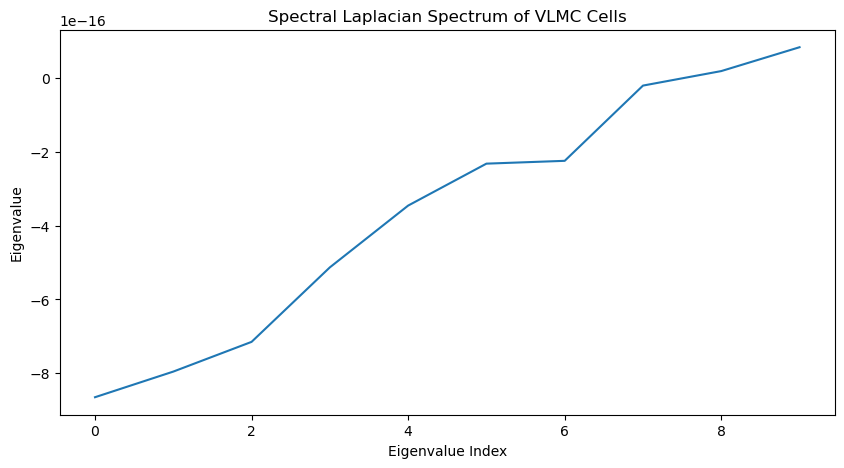

In [15]:
spectra_gt = spectral_laplacian_spectrum_by_cell_class(
    ground_truth_sample,
    cell_class_value='VLMC',
    mode='radius',
    k=None,
    radius=0.025,
    weight='binary',
    sigma=None,
    laplacian='normalized',
    n_eigs=10,
    drop_self_loops=True,
    random_state=0,
)

#print eigenvalues
print(spectra_gt.eigenvalues)


# Plot the spectrum
plt.figure(figsize=(10, 5))
plt.plot(spectra_gt.eigenvalues)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Spectral Laplacian Spectrum of VLMC Cells')
plt.show()


[-9.65402602e-16 -8.01645638e-16 -5.65404909e-16 -4.84461918e-16
 -3.26836464e-16 -2.61641961e-16 -2.08531328e-16 -8.55128131e-17
  2.76112358e-17  1.48844185e-16]


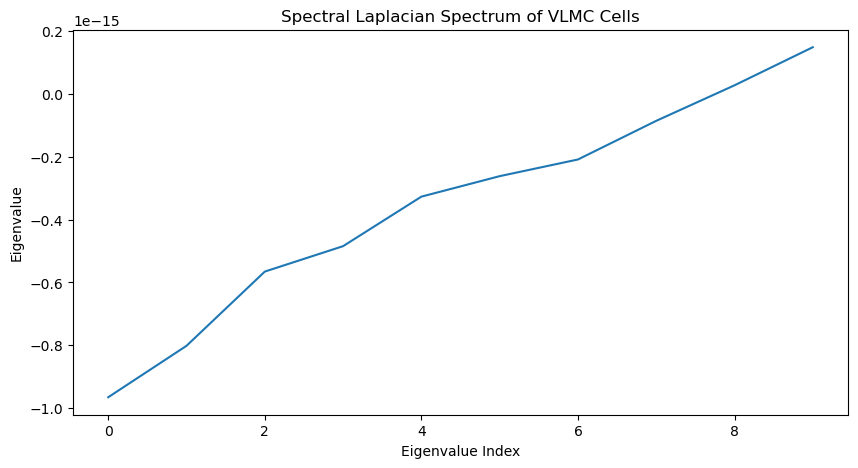

In [16]:
spectra_gt_2 = spectral_laplacian_spectrum_by_cell_class(
    ground_truth_sample,
    cell_class_value='VLMC',
    mode='radius',
    k=None,
    radius=0.025,
    weight='gaussian',
    sigma=None,
    laplacian='normalized',
    n_eigs=10,
    drop_self_loops=True,
    random_state=0,
)

#print eigenvalues
print(spectra_gt_2.eigenvalues)

# Plot the spectrum
plt.figure(figsize=(10, 5))
plt.plot(spectra_gt_2.eigenvalues)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Spectral Laplacian Spectrum of VLMC Cells')
plt.show()


[-1.01368108e-15 -5.00034058e-16 -4.43462015e-16 -2.87621012e-16
 -2.26918950e-16 -8.31180402e-17 -6.60647039e-17 -3.09157325e-17
  0.00000000e+00  2.07902527e-17]


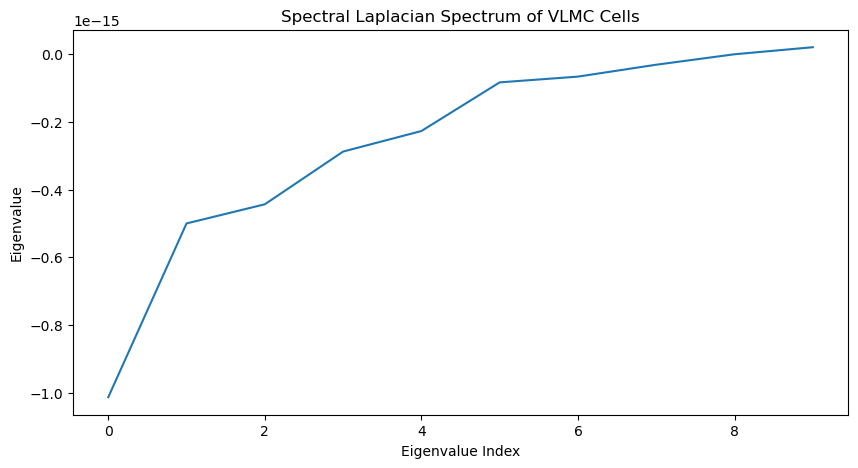

In [17]:
spectral_test = spectral_laplacian_spectrum_by_cell_class(
    pred_sample,
    cell_class_value='VLMC',
    mode='radius',
    k=None,
    radius=0.025,
    weight='gaussian',
    sigma=None,
    laplacian='normalized',
    n_eigs=10,
    drop_self_loops=True,
    random_state=0,
)

#print eigenvalues
print(spectral_test.eigenvalues)

# Plot the spectrum
plt.figure(figsize=(10, 5))
plt.plot(spectral_test.eigenvalues)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Spectral Laplacian Spectrum of VLMC Cells')
plt.show()


In [18]:
# compare the entropy of the two spectra 

print(spectral_test.von_neumann_entropy)
print(spectra_gt_2.von_neumann_entropy)

3.8881657022974663
3.937389258762339


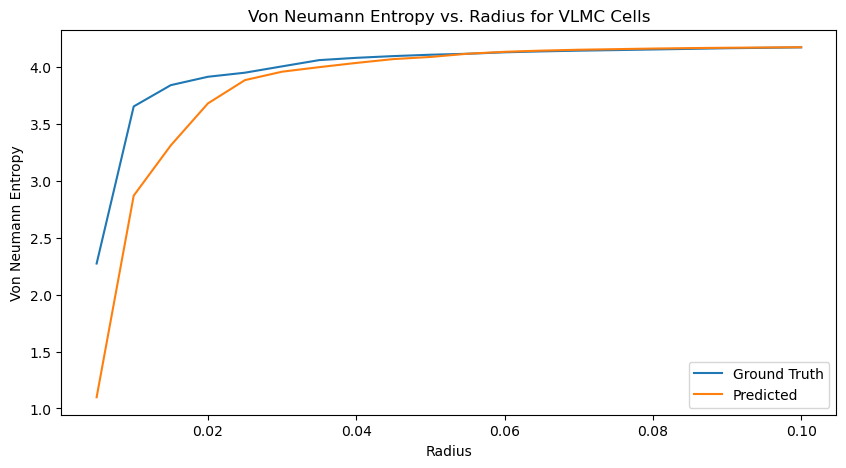

In [19]:
# script that takes the two point clouds as input and computes the von Neumann entropy of the two spectra 
# for various values of radius spanning from 0.2 to 0.01 with 20 steps

entropy_gt = []
entropy_test = []
radius_values = np.linspace(0.1, 0.005, 20)

for radius in radius_values:
    spectral_gt = spectral_laplacian_spectrum_by_cell_class(
        ground_truth_sample,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
    )
    entropy_gt.append(spectral_gt.von_neumann_entropy)

    spectral_test = spectral_laplacian_spectrum_by_cell_class(
        pred_sample,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
    )
    entropy_test.append(spectral_test.von_neumann_entropy)

# plot the entropy of the two spectra as a function of the radius
plt.figure(figsize=(10, 5))
plt.plot(radius_values, entropy_gt, label="Ground Truth")
plt.plot(radius_values, entropy_test, label="Predicted")
plt.xlabel('Radius')
plt.ylabel('Von Neumann Entropy')
plt.title('Von Neumann Entropy vs. Radius for VLMC Cells')
plt.legend()
plt.show()




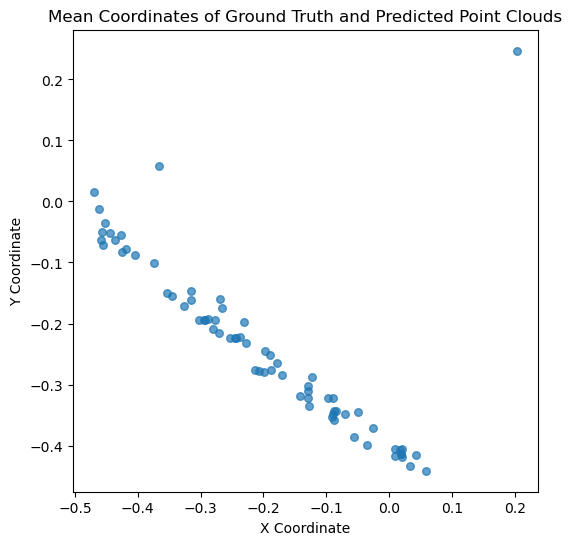

In [20]:
# compute the mean values of coordinates between the two point clouds
# we want a new point cloud that is the average of the two existing ones 

# get the coordinates of the two point clouds
coords_gt = ground_truth_sample[['coord_X', 'coord_Y']].values
coords_pred = aligned_pred_sample[['coord_X', 'coord_Y']].values

# compute the mean values of the coordinates
mean_coords = np.mean([coords_gt, coords_pred], axis=0)

# plot the mean coordinates
plt.figure(figsize=(6, 6))
plt.scatter(mean_coords[:, 0], mean_coords[:, 1], s=30, alpha=0.7)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Mean Coordinates of Ground Truth and Predicted Point Clouds')
plt.show()

In [21]:
# make a new dataframe with the mean coordinates
mean_coords_df = pd.DataFrame(mean_coords, columns=['coord_X', 'coord_Y'])
mean_coords_df['cell_class'] = 'VLMC'
mean_coords_df['cell_name'] = 'mean_coords'
mean_coords_df['sample_id'] = 'mean_coords'
mean_coords_df['cell_section'] = 'mean_coords'


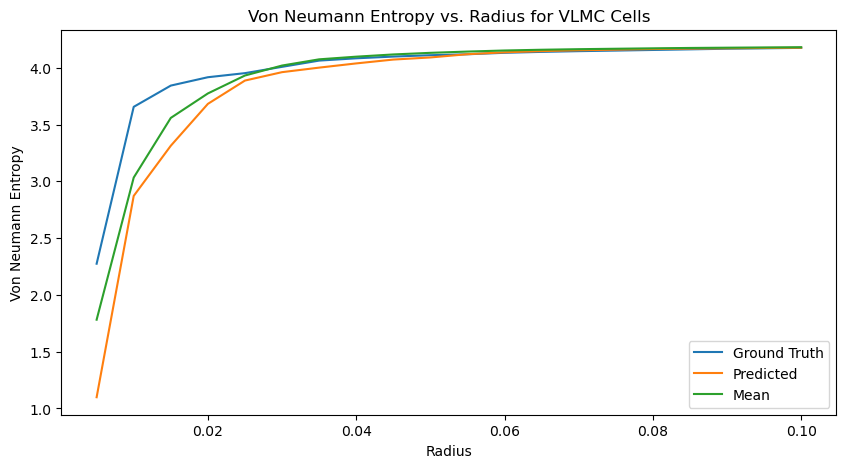

In [22]:
# script that takes the two point clouds as input and computes the von Neumann entropy of the two spectra 
# for various values of radius spanning from 0.2 to 0.01 with 20 steps

entropy_gt = []
entropy_test = []
entropy_mean = []
radius_values = np.linspace(0.1, 0.005, 20)

for radius in radius_values:
    spectral_gt = spectral_laplacian_spectrum_by_cell_class(
        ground_truth_sample,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        use_shift_invert=False,
    )
    entropy_gt.append(spectral_gt.von_neumann_entropy)

    spectral_test = spectral_laplacian_spectrum_by_cell_class(
        pred_sample,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        use_shift_invert=False,
    )
    entropy_test.append(spectral_test.von_neumann_entropy)
    
    spectral_mean = spectral_laplacian_spectrum_by_cell_class(
        mean_coords_df,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        use_shift_invert=False,
    )
    entropy_mean.append(spectral_mean.von_neumann_entropy)

# plot the entropy of the two spectra as a function of the radius
plt.figure(figsize=(10, 5))
plt.plot(radius_values, entropy_gt, label="Ground Truth")
plt.plot(radius_values, entropy_test, label="Predicted")
plt.plot(radius_values, entropy_mean, label="Mean")
plt.xlabel('Radius')
plt.ylabel('Von Neumann Entropy')
plt.title('Von Neumann Entropy vs. Radius for VLMC Cells')
plt.legend()
plt.show()


71


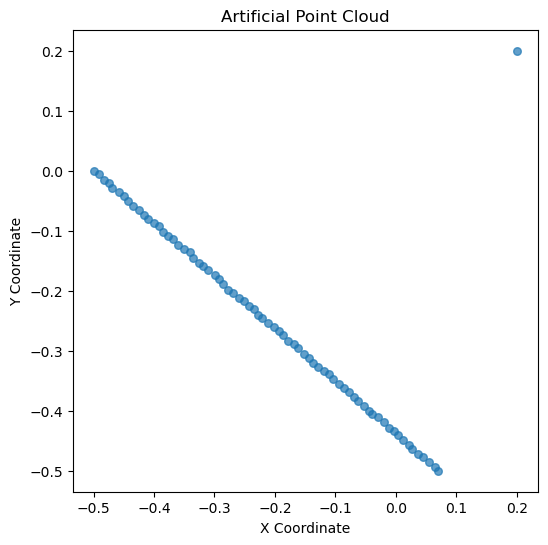

In [23]:
# number of cells in the ground truth
print(len(ground_truth_sample))
n_cells = len(ground_truth_sample)

# create an artificial point cloud with cells evenly placed in a line
start_x = -0.5
end_x = 0.07
start_y = 0
end_y = -0.5

# create a new dataframe with the artificial point cloud
artificial_coords_x = np.linspace(start_x, end_x, n_cells-1)
artificial_coords_y = np.linspace(start_y, end_y, n_cells-1)  
# add small random noise to the coordinates
artificial_coords_x = artificial_coords_x + np.random.normal(0, 0.001, n_cells-1)
artificial_coords_y = artificial_coords_y + np.random.normal(0, 0.001, n_cells-1)
# add one point isolated in 0.2, 0.2
artificial_coords_x = np.append(artificial_coords_x, 0.2)
artificial_coords_y = np.append(artificial_coords_y, 0.2)
artificial_coords_df = pd.DataFrame(artificial_coords_x, columns=['coord_X'])
artificial_coords_df['coord_Y'] = artificial_coords_y
artificial_coords_df['cell_class'] = 'VLMC'
artificial_coords_df['cell_name'] = 'artificial_coords'
artificial_coords_df['sample_id'] = 'artificial_coords'
artificial_coords_df['cell_section'] = 'artificial_coords'

# plot the artificial point cloud
plt.figure(figsize=(6, 6))
plt.scatter(artificial_coords_df['coord_X'], artificial_coords_df['coord_Y'], s=30, alpha=0.7)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Artificial Point Cloud')
plt.show()

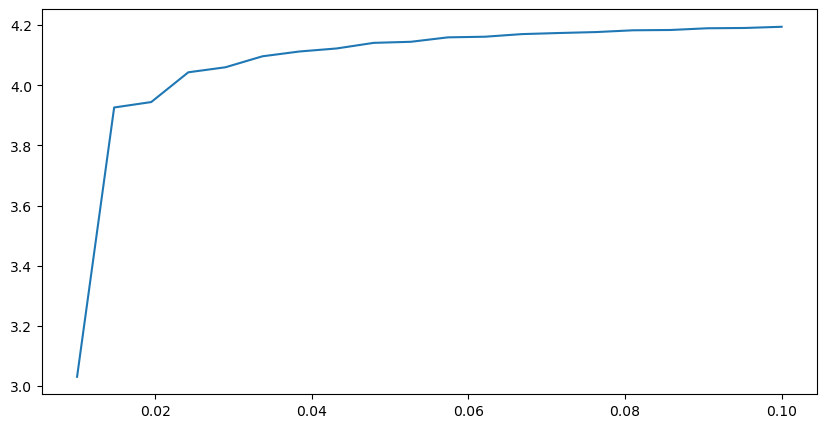

In [24]:
entropy_artificial = []
radius_values = np.linspace(0.1, 0.01, 20)

for radius in radius_values:
    spectral_artificial = spectral_laplacian_spectrum_by_cell_class(
        artificial_coords_df,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        use_shift_invert=False,
    )
    entropy_artificial.append(spectral_artificial.von_neumann_entropy)

# plot
plt.figure(figsize=(10, 5))
plt.plot(radius_values, entropy_artificial, label="Artificial")
plt.show()

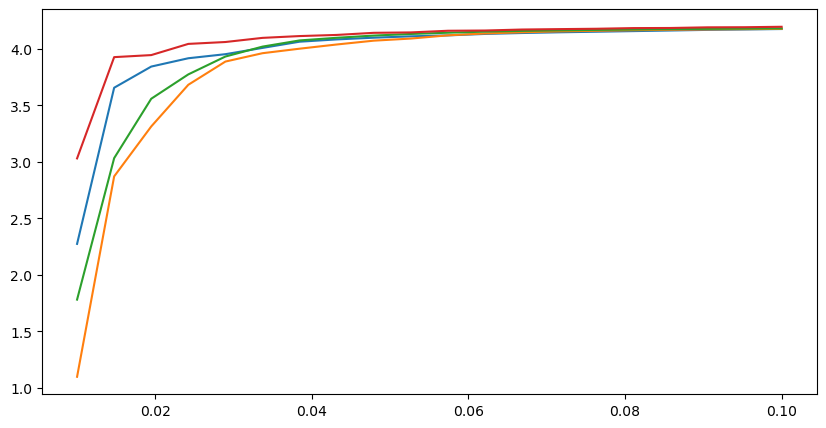

In [25]:
# all plots in one figure
plt.figure(figsize=(10, 5))
plt.plot(radius_values, entropy_gt, label="Ground Truth")
plt.plot(radius_values, entropy_test, label="Predicted")
plt.plot(radius_values, entropy_mean, label="Mean")
plt.plot(radius_values, entropy_artificial, label="Artificial")
plt.show()

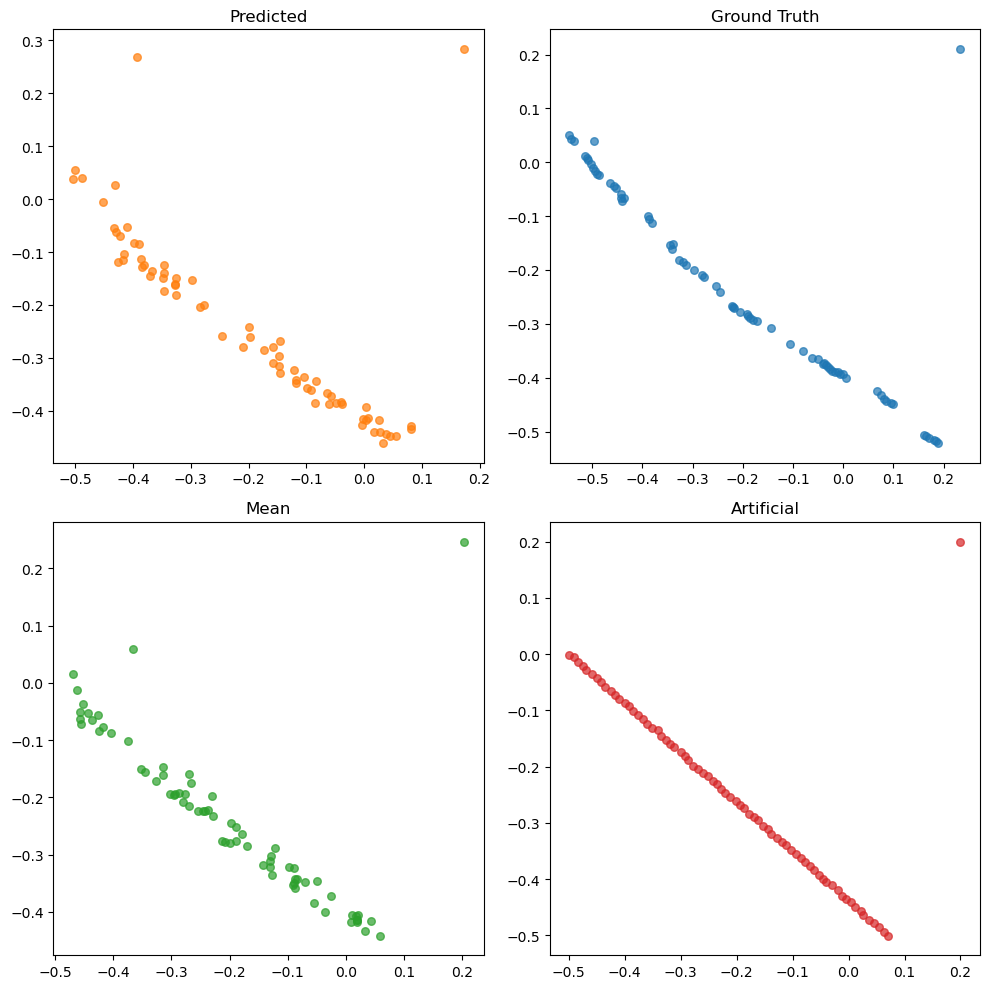

In [30]:
# plot of all the four different point clouds on 4 subplots with different colors
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(aligned_pred_sample['coord_X'], aligned_pred_sample['coord_Y'], s=30, alpha=0.7, color='tab:orange', label='Predicted')
plt.title('Predicted')
plt.subplot(2, 2, 2)
plt.scatter(ground_truth_sample['coord_X'], ground_truth_sample['coord_Y'], s=30, alpha=0.7, color='tab:blue', label='Ground Truth')
plt.title('Ground Truth')
plt.subplot(2, 2, 3)
plt.scatter(mean_coords_df['coord_X'], mean_coords_df['coord_Y'], s=30, alpha=0.7, color='tab:green', label='Mean')
plt.title('Mean')
plt.subplot(2, 2, 4)
plt.scatter(artificial_coords_df['coord_X'], artificial_coords_df['coord_Y'], s=30, alpha=0.7, color='tab:red', label='Artificial')
plt.title('Artificial')
plt.tight_layout()
plt.show()




## spherical toy example

bla bla bla we build three spheres with different distributions and try to plot the diagram

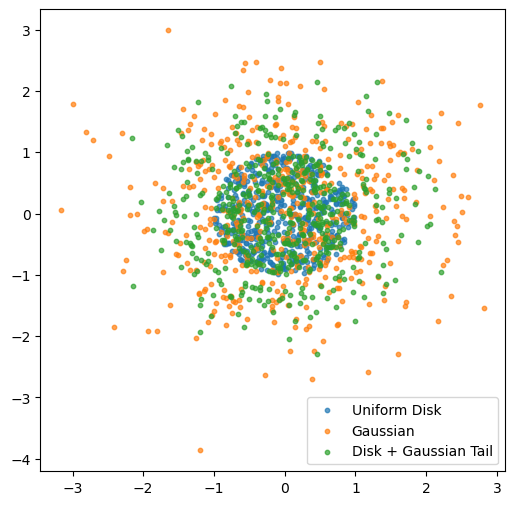

In [2]:
# build three point distributions

n = 512

# Uniform random disk with hard boundary
r = np.sqrt(np.random.rand(n))  # radius: sqrt to ensure uniform density in the disk
theta = 2 * np.pi * np.random.rand(n)  # angle
disk_points = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

# Isotropic 2D Gaussian
gaussian_points = np.random.randn(n, 2)

# Disk with a gaussian tail: concatenate points inside disk and a tail of points outside disk
n_disk = int(0.6 * n)
n_tail = n - n_disk

# Disk points for main body
r_tail_disk = np.sqrt(np.random.rand(n_disk))
theta_tail_disk = 2 * np.pi * np.random.rand(n_disk)
disk_main = np.stack([r_tail_disk * np.cos(theta_tail_disk), r_tail_disk * np.sin(theta_tail_disk)], axis=1)

# Gaussian tail: points at larger radius, centered at the disk edge, with higher spread
tail_radius_center = 1.2  # start the tail just outside the disk
tail_r = tail_radius_center + 0.5 * np.abs(np.random.randn(n_tail))
tail_theta = 2 * np.pi * np.random.rand(n_tail)
tail_points = np.stack([tail_r * np.cos(tail_theta), tail_r * np.sin(tail_theta)], axis=1)

# Concatenate to form disk+tail
disk_gauss_tail_points = np.concatenate([disk_main, tail_points], axis=0)

# plot the three point distributions with smaller dots
plt.figure(figsize=(6, 6))
plt.scatter(disk_points[:, 0], disk_points[:, 1], s=10, alpha=0.7, label='Uniform Disk')
plt.scatter(gaussian_points[:, 0], gaussian_points[:, 1], s=10, alpha=0.7, label='Gaussian')
plt.scatter(disk_gauss_tail_points[:, 0], disk_gauss_tail_points[:, 1], s=10, alpha=0.7, label='Disk + Gaussian Tail')
plt.legend()
plt.show()

 

In [3]:
# build the dataframes for the three point distributions
disk_points_df = pd.DataFrame(disk_points, columns=['coord_X', 'coord_Y'])
gaussian_points_df = pd.DataFrame(gaussian_points, columns=['coord_X', 'coord_Y'])
disk_gauss_tail_points_df = pd.DataFrame(disk_gauss_tail_points, columns=['coord_X', 'coord_Y'])

# bla bla bla
disk_points_df['cell_class'] = 'VLMC'
disk_points_df['cell_name'] = 'disk_points'
disk_points_df['sample_id'] = 'disk_points'
disk_points_df['cell_section'] = 'disk_points'

gaussian_points_df['cell_class'] = 'VLMC'
gaussian_points_df['cell_name'] = 'gaussian_points'
gaussian_points_df['sample_id'] = 'gaussian_points'
gaussian_points_df['cell_section'] = 'gaussian_points'

disk_gauss_tail_points_df['cell_class'] = 'VLMC'
disk_gauss_tail_points_df['cell_name'] = 'disk_gauss_tail_points'
disk_gauss_tail_points_df['sample_id'] = 'disk_gauss_tail_points'
disk_gauss_tail_points_df['cell_section'] = 'disk_gauss_tail_points'



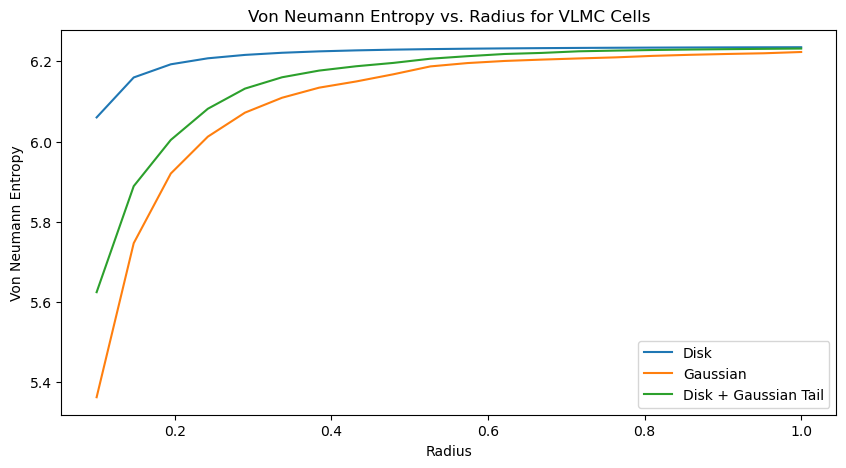

In [ ]:
# script that takes the three point clouds as input and computes the von Neumann entropy of their spectra 
# for various values of radius spanning from 1 to 0.05 with 20 steps
from spectral_graph import spectral_laplacian_spectrum_by_cell_class

entropy_disk = []
entropy_gaussian = []
entropy_disk_gauss_tail = []
radius_values = np.linspace(1, 0.1, 20)

for radius in radius_values:
    spectral_disk = spectral_laplacian_spectrum_by_cell_class(
        disk_points_df,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        solver='dense'
    )
    entropy_disk.append(spectral_disk.von_neumann_entropy)

    spectral_gaussian = spectral_laplacian_spectrum_by_cell_class(
        gaussian_points_df,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        solver='dense'
    )
    entropy_gaussian.append(spectral_gaussian.von_neumann_entropy)
    
    spectral_disk_gauss_tail = spectral_laplacian_spectrum_by_cell_class(
        disk_gauss_tail_points_df,
        cell_class_value='VLMC',
        mode='radius',
        k=None,
        radius=radius,
        weight='gaussian',
        sigma=0.7*radius,
        laplacian='normalized',
        n_eigs=10,
        drop_self_loops=True,
        random_state=0,
        use_shift_invert=True,
    )
    entropy_disk_gauss_tail.append(spectral_disk_gauss_tail.von_neumann_entropy)

# plot the entropy of the three spectra as a function of the radius
plt.figure(figsize=(10, 5))
plt.plot(radius_values, entropy_disk, label="Disk")
plt.plot(radius_values, entropy_gaussian, label="Gaussian")
plt.plot(radius_values, entropy_disk_gauss_tail, label="Disk + Gaussian Tail")
plt.xlabel('Radius')
plt.ylabel('Von Neumann Entropy')
plt.title('Von Neumann Entropy vs. Radius for VLMC Cells')
plt.legend()
plt.show()


## whole measurement for slice

['Astro', 'Endo', 'L2/3 IT', 'L4/5 IT', 'L5 ET', 'L5 IT', 'L5/6 NP', 'L6 CT', 'L6 IT', 'L6b', 'Lamp5', 'Micro', 'OPC', 'Oligo', 'PVM', 'Peri', 'Pvalb', 'SMC', 'Sncg', 'Sst', 'VLMC', 'Vip']


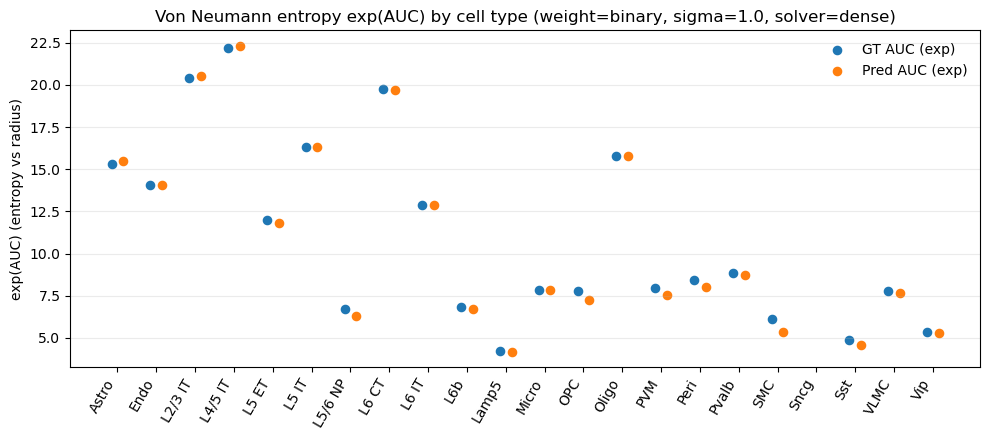

In [ ]:
from script import *
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Tuple

radius_values = np.linspace(0.5, 0.005, 20)
weight = "binary"
sigma = 1.0  # NOTE: for fair comparisons, keep sigma fixed across GT and Pred
laplacian = "normalized"
n_eigs = 10
solver = "dense"  # robust for ~500 nodes / toy examples

# ---- Load data ----
gt = whole_ground_truth_sample
pred = whole_pred_sample

# ---- Iterate cell types ----
cell_types = sorted(set(gt["cell_class"].dropna().unique()).intersection(pred["cell_class"].dropna().unique()))

print(cell_types)

results: Dict[str, Dict[str, float]] = {}
curves: Dict[str, Dict[str, List[float]]] = {}

for ct in cell_types:
    ent_gt = entropy_curve_for_cell_type(
        gt,
        ct,
        radius_values,
        weight=weight,
        sigma=sigma,
        laplacian=laplacian,
        n_eigs=n_eigs,
        solver=solver,
    )
    ent_pred = entropy_curve_for_cell_type(
        pred,
        ct,
        radius_values,
        weight=weight,
        sigma=sigma,
        laplacian=laplacian,
        n_eigs=n_eigs,
        solver=solver,
    )

    auc_gt = auc_trapz(radius_values, np.array(ent_gt, dtype=float))
    auc_pred = auc_trapz(radius_values, np.array(ent_pred, dtype=float))

    results[str(ct)] = {"auc_gt": float(auc_gt), "auc_pred": float(auc_pred)}
    curves[str(ct)] = {"entropy_gt": ent_gt, "entropy_pred": ent_pred}





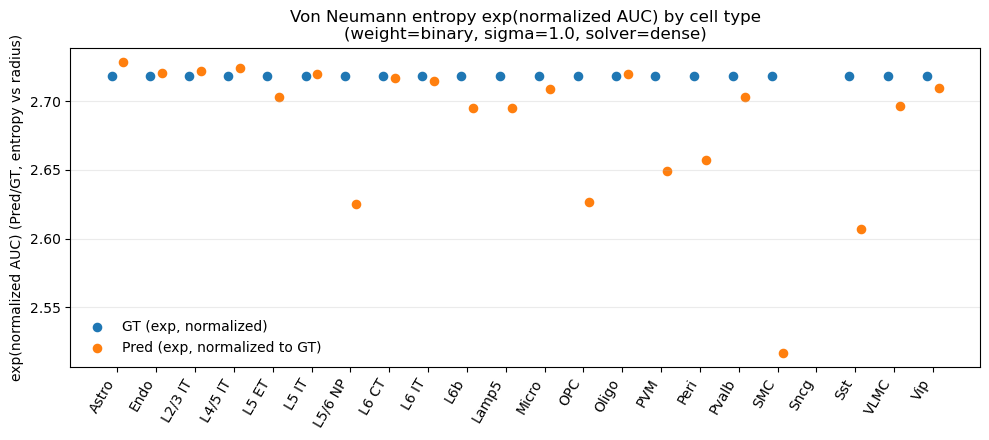

In [42]:
# ---- Plot normalized exp(AUC) comparison (one figure for all cell types) ----
cell_types_plot = list(results.keys())
x = np.arange(len(cell_types_plot), dtype=float)
y_gt = np.array([results[c]["auc_gt"] for c in cell_types_plot], dtype=float)
y_pred = np.array([results[c]["auc_pred"] for c in cell_types_plot], dtype=float)

# Normalize AUC values to GT for each cell type, then exponentiate to enhance spread
# The GT values become 1, the Pred values are relative to GT and can show >1 or <1
with np.errstate(divide="ignore", invalid="ignore"):
    y_pred_norm = np.where(y_gt != 0, y_pred / y_gt, np.nan)
    y_pred_norm_exp = np.exp(y_pred_norm)
    y_gt_norm_exp = np.exp(y_gt / y_gt)  # always np.exp(1) = e ~2.718 for valid cell types

fig, ax = plt.subplots(figsize=(max(10, 0.35 * len(cell_types_plot)), 4.5))
ax.scatter(x - 0.15, y_gt_norm_exp, label="GT (exp, normalized)", s=35)
ax.scatter(x + 0.15, y_pred_norm_exp, label="Pred (exp, normalized to GT)", s=35)

ax.set_xticks(x)
ax.set_xticklabels(cell_types_plot, rotation=60, ha="right")
ax.set_ylabel("exp(normalized AUC) (Pred/GT, entropy vs radius)")
ax.set_title(f"Von Neumann entropy exp(normalized AUC) by cell type\n(weight={weight}, sigma={sigma}, solver={solver})")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [51]:
# print the real auc values of gt for all cell types
for ct in cell_types:
    print(f"{ct}: {results[ct]['auc_gt']}")


Astro: 2.7293169900729706
Endo: 2.6432637463231567
L2/3 IT: 3.0170339015228564
L4/5 IT: 3.0989373947372454
L5 ET: 2.482328355268696
L5 IT: 2.7924491022410414
L5/6 NP: 1.9045792339145855
L6 CT: 2.983482114910095
L6 IT: 2.5570416664511413
L6b: 1.9227361774492129
Lamp5: 1.4408137763552686
Micro: 2.0622714555316497
OPC: 2.0539082051974464
Oligo: 2.7585320199780456
PVM: 2.070080882441295
Peri: 2.1294359090342962
Pvalb: 2.1816244070277184
SMC: 1.8154975814518226
Sncg: nan
Sst: 1.5849896426132737
VLMC: 2.05446095115652
Vip: 1.670982217833792


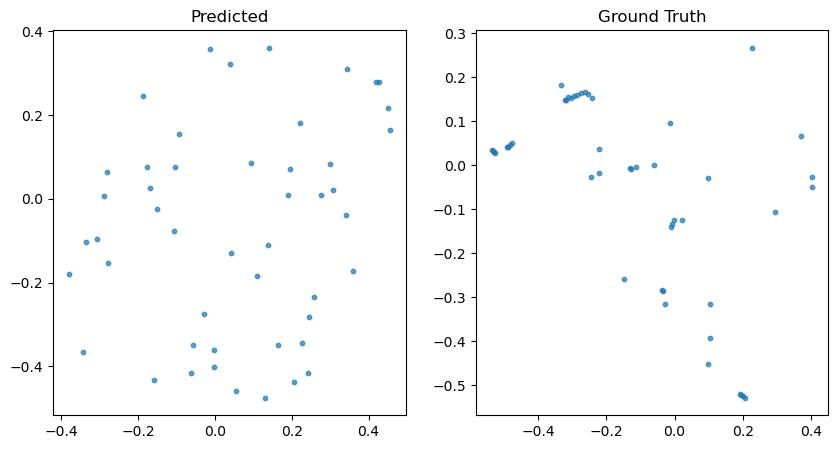

In [60]:
# get only the VLMC cells
pred_sample_smc = whole_pred_sample[whole_pred_sample['cell_class'] == 'SMC']
ground_truth_sample_smc = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'SMC']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_smc['coord_X'], pred_sample_smc['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_smc['coord_X'], ground_truth_sample_smc['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()


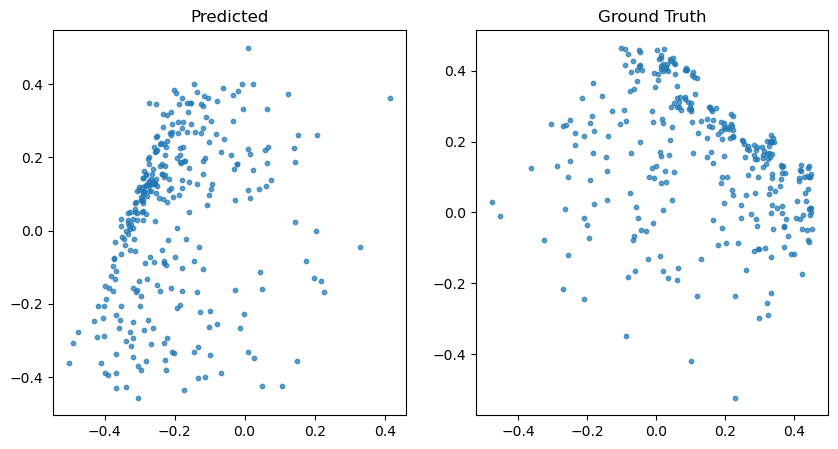

In [61]:
# get only the VLMC cells
pred_sample_smc = whole_pred_sample[whole_pred_sample['cell_class'] == 'Oligo']
ground_truth_sample_smc = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'Oligo']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_smc['coord_X'], pred_sample_smc['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_smc['coord_X'], ground_truth_sample_smc['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()

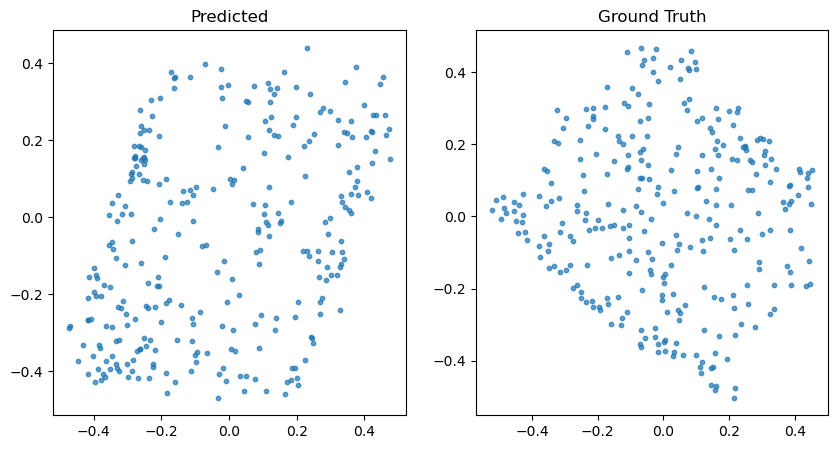

In [46]:
# get only the VLMC cells
pred_sample_astro = whole_pred_sample[whole_pred_sample['cell_class'] == 'Astro']
ground_truth_sample_astro = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'Astro']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_astro['coord_X'], pred_sample_astro['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_astro['coord_X'], ground_truth_sample_astro['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()

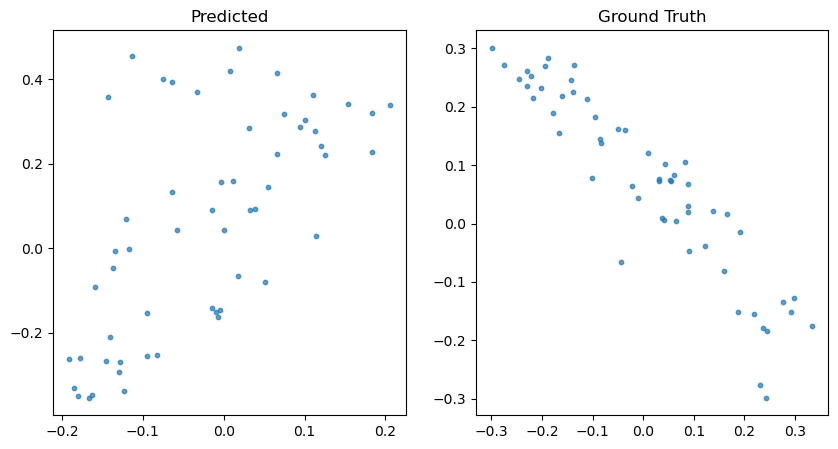

In [48]:
# get only the VLMC cells
pred_sample_56np = whole_pred_sample[whole_pred_sample['cell_class'] == 'L5/6 NP']
ground_truth_sample_56np = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'L5/6 NP']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_56np['coord_X'], pred_sample_56np['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_56np['coord_X'], ground_truth_sample_56np['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()

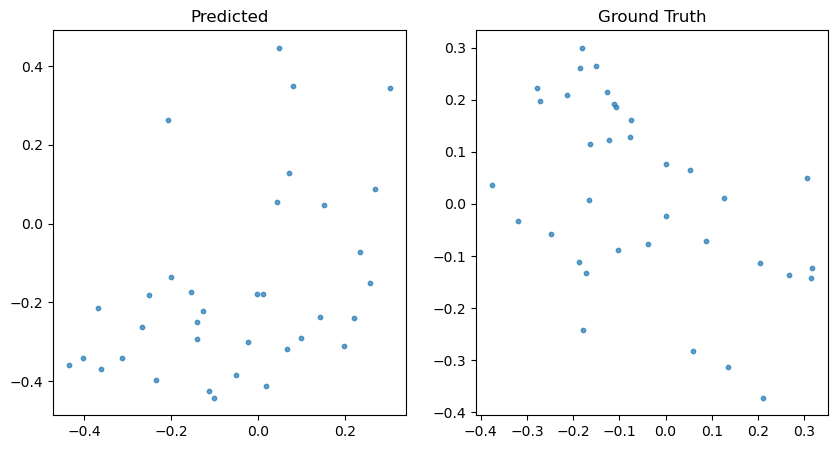

In [49]:
# get only the VLMC cells
pred_sample_sst = whole_pred_sample[whole_pred_sample['cell_class'] == 'Sst']
ground_truth_sample_sst = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'Sst']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_sst['coord_X'], pred_sample_sst['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_sst['coord_X'], ground_truth_sample_sst['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()

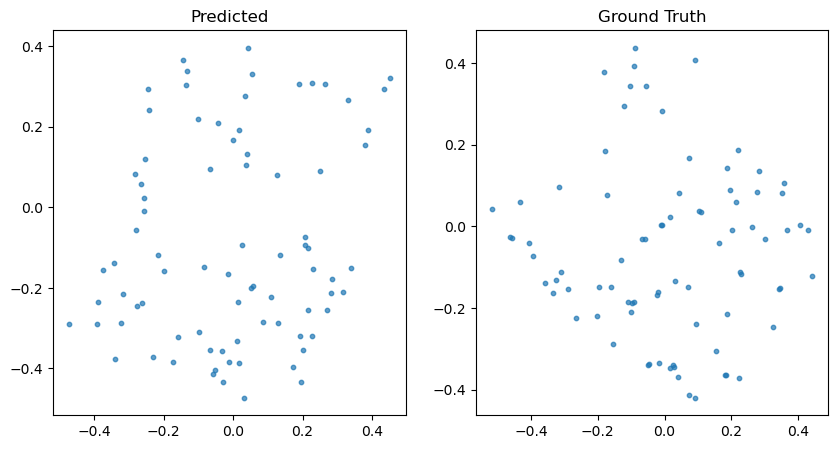

In [50]:
# get only the VLMC cells
pred_sample_opc = whole_pred_sample[whole_pred_sample['cell_class'] == 'OPC']
ground_truth_sample_opc = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'OPC']

# plot the two point clouds on two subplots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pred_sample_opc['coord_X'], pred_sample_opc['coord_Y'], s=10, alpha=0.7, label='Predicted')
plt.title('Predicted')
plt.subplot(1, 2, 2)
plt.scatter(ground_truth_sample_opc['coord_X'], ground_truth_sample_opc['coord_Y'], s=10, alpha=0.7, label='Ground Truth')
plt.title('Ground Truth')
plt.show()

# Heat Kernel Signature

## defining and introducing concepts

we want to compute the HKS over a graph, and may be try different versions of graph building sequencies, from radius linked to fully connected graph 

In [2]:
pred = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_pred.csv'
ground_truth = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_true.csv'

# load the samples
whole_pred_sample = pd.read_csv(pred)
whole_ground_truth_sample = pd.read_csv(ground_truth)

In [3]:
from spectral_graph import hks_per_node, _spatial_adjacency_from_coords, plot_hks_video
import IPython
from IPython.display import HTML
import ipywidgets as widgets

In [ ]:
fig, ax, controls = plot_hks_video(whole_ground_truth_sample, min_time=0.00001, max_time=2, n_points=32, cell_class_value="SMC",
    coord_cols=("coord_X", "coord_Y"), mode="knn", k=32, radius=0.2, weight="gaussian", scale="log",
    sigma=1, laplacian="normalized", n_eigs=32, drop_self_loops=True, random_state=0, 
    use_shift_invert=True, solver="auto", dense_solver_max_n=100000, cmap="magma", node_size=48.0,
    edge_color="#9a9a9a", edge_alpha=0.02, max_edges=100000, figsize=(7.0, 6.0), interval=250, 
    save_path=None, dpi=150, title=None)

In [8]:
fig, ax, controls = plot_hks_video(whole_pred_sample, min_time=0.00001, max_time=2, n_points=32, cell_class_value="SMC",
    coord_cols=("coord_X", "coord_Y"), mode="knn", k=32, radius=0.2, weight="gaussian", scale="log",
    sigma=1, laplacian="normalized", n_eigs=32, drop_self_loops=True, random_state=0, 
    use_shift_invert=True, solver="auto", dense_solver_max_n=100000, cmap="magma", node_size=48.0,
    edge_color="#9a9a9a", edge_alpha=0.02, max_edges=100000, figsize=(7.0, 6.0), interval=250, 
    save_path=None, dpi=150, title=None)